# GSoC 2026 — ML4SCI CMS: Linear Attention ViT
## Task 2h: End-to-End Mass Regression & Classification with MAE Pretraining

**Architecture:** Vision Transformer with Katharopoulos linear attention (O(n) complexity)

**Pipeline:**
1. MAE self-supervised pretraining on unlabelled particle physics data (30GB)
2. Finetuning for mass regression (L1) + particle classification (CrossEntropy)
3. From-scratch baseline comparison

**Key design choices:**
- Linear attention: φ(x) = elu(x)+1 kernel → O(Nd²) instead of O(N²d)
- Asymmetric MAE: heavy encoder + lightweight decoder
- Differential learning rates for finetuning
- Full regularization stack: dropout, weight decay, label smoothing, early stopping, augmentation

**Evaluation metrics:**
- Classification: Accuracy, AUC-ROC, Confusion Matrix
- Regression: MAE (L1), R² score, Predicted-vs-True scatter

## 0. Session Setup
Run this at the start of every Colab session to mount Drive and copy datasets locally.

In [ ]:

# STEP 1: Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_DIR = '/content/drive/MyDrive/GSoC_ML4SCI'
os.makedirs(DRIVE_DIR, exist_ok=True)


Mounted at /content/drive


In [ ]:

# STEP 2: Download from CERNBox → Drive (only if not already there)
FILES = {
    'Dataset_Specific_Unlabelled.h5': 'https://cernbox.cern.ch/remote.php/dav/public-files/e3pqxcIznqdYyRv/Dataset_Specific_Unlabelled.h5',
    'Dataset_Specific_labelled.h5': 'https://cernbox.cern.ch/remote.php/dav/public-files/e3pqxcIznqdYyRv/Dataset_Specific_labelled.h5',
}

for fname, url in FILES.items():
    dest = f'{DRIVE_DIR}/{fname}'
    if os.path.exists(dest):
        size_gb = os.path.getsize(dest) / 1e9
        print(f"✓ {fname} already on Drive ({size_gb:.1f} GB)")
    else:
        print(f"⏳ Downloading {fname} from CERNBox → Drive...")
        !wget -q --show-progress -O "{dest}" "{url}"
        size_gb = os.path.getsize(dest) / 1e9
        print(f"✓ Done ({size_gb:.1f} GB)")


✓ Dataset_Specific_Unlabelled.h5 already on Drive (30.0 GB)
✓ Dataset_Specific_labelled.h5 already on Drive (5.0 GB)


In [ ]:

# STEP 3: Copy from Drive → local SSD (every session)
FILES = {
    'Dataset_Specific_Unlabelled.h5': 'https://cernbox.cern.ch/remote.php/dav/public-files/e3pqxcIznqdYyRv/Dataset_Specific_Unlabelled.h5',
    'Dataset_Specific_labelled.h5': 'https://cernbox.cern.ch/remote.php/dav/public-files/e3pqxcIznqdYyRv/Dataset_Specific_labelled.h5',
}
for fname in FILES:
    local = f'/content/{fname}'
    if not os.path.exists(local):
        print(f"⏳ Copying {fname} to local SSD...")
        !cp "{DRIVE_DIR}/{fname}" "{local}"
        print(f"✓ {fname} copied")
    else:
        print(f"✓ {fname} already local")

print("\nReady!")

⏳ Copying Dataset_Specific_Unlabelled.h5 to local SSD...
✓ Dataset_Specific_Unlabelled.h5 copied
⏳ Copying Dataset_Specific_labelled.h5 to local SSD...
✓ Dataset_Specific_labelled.h5 copied

Ready!


## 1. Imports & Reproducibility

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score, roc_curve, r2_score
)
import os, math, random, time
from collections import defaultdict


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Using device: cuda
GPU: NVIDIA A100-SXM4-40GB
Memory: 42.4 GB


## 2. Dataset Exploration (Phase 0)

**Run this first** — the shapes and keys determine every architectural dimension.
Update the `Config` class in the next cell based on what you see here.


Dataset_Specific_Unlabelled.h5
  Key: 'jet'
    shape: (60000, 125, 125, 8)
    dtype: float32
    min:   0.0000
    max:   255.0000


Dataset_Specific_labelled.h5
  Key: 'Y'
    shape: (10000, 1)
    dtype: float32
    min:   0.0000
    max:   1.0000

  Key: 'jet'
    shape: (10000, 125, 125, 8)
    dtype: float32
    min:   0.0000
    max:   255.0000



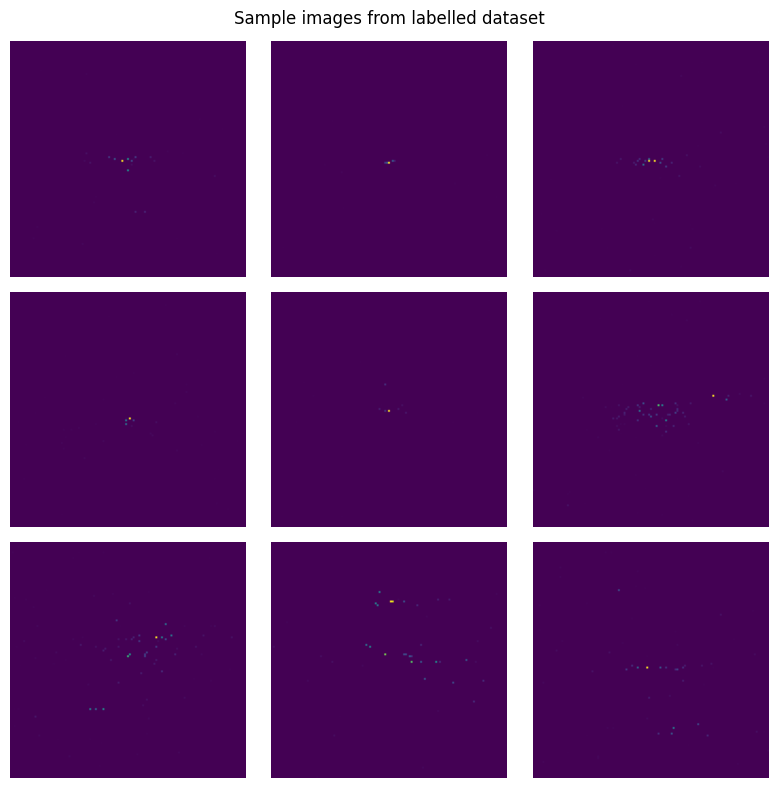

In [ ]:

# EXPLORE BOTH DATASETS — shapes, keys, dtypes, value ranges

for fname in ['Dataset_Specific_Unlabelled.h5', 'Dataset_Specific_labelled.h5']:
    path = f'/content/{fname}'
    print(f"\n{'='*60}")
    print(f"{fname}")
    print(f"{'='*60}")
    with h5py.File(path, 'r') as f:
        for k in f.keys():
            ds = f[k]
            print(f"  Key: '{k}'")
            print(f"    shape: {ds.shape}")
            print(f"    dtype: {ds.dtype}")
            print(f"    min:   {ds[:100].min():.4f}")
            print(f"    max:   {ds[:100].max():.4f}")
            if ds.ndim == 1:
                unique = np.unique(ds[:10000])
                print(f"    unique (first 10k): {unique}")
            print()

# ── Visualize a few samples ──
with h5py.File('/content/Dataset_Specific_labelled.h5', 'r') as f:
    # UPDATE 'X' to whatever the image key actually is
    imgs = f['jet'][:9]  # Replaced cfg.image_key with 'jet'

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    img = imgs[i]
    if img.ndim == 3:
        img = img[0] if img.shape[0] <= 3 else img[:,:,0]
    ax.imshow(img, cmap='viridis')
    ax.axis('off')
plt.suptitle('Sample images from labelled dataset')
plt.tight_layout()
plt.show()

## 3. Configuration

**Updated after dataset exploration:**
- `img_size=125` — actual image dimensions from the h5 files
- `patch_size=5` — divides 125 evenly → 25×25 = 625 patches per image
- `embed_dim=192`, `num_heads=6` — 192/6 = 32 dims per head (standard)

Note: 625 patches is significantly more than a typical ViT (196 for 224×224/16).
Linear attention's O(Nd²) scaling handles this gracefully — softmax O(N²d) would
mean a 625×625 = 390,625-entry attention matrix per head per layer. That's exactly
why we chose linear attention for this task.

In [ ]:
class Config:


    img_size = 125          # 125×125 images
    num_channels = 8        # 8-channel jet image
    num_classes = 2         # Binary classification
    image_key = 'jet'       # HDF5 key for images
    label_key = 'Y'         # HDF5 key for class labels
    mass_key = 'am'         # HDF5 key for jet mass (in full dataset)

    # ── Architecture
    patch_size = 5          # 125/5 = 25 patches per side (625 total)
    embed_dim = 192
    num_heads = 6
    num_layers = 6
    mlp_ratio = 4
    dropout = 0.1

    # ── MAE Pretraining
    mask_ratio = 0.75
    decoder_embed_dim = 96
    decoder_num_heads = 3
    decoder_num_layers = 2

    # ── Training
    pretrain_epochs = 30        # was 10 — need more epochs for encoder to learn
    finetune_epochs = 20        # was 10 — let both models converge
    pretrain_lr = 1.5e-4        # was 1.5e-5 — standard MAE LR, safe with bfloat16
    finetune_backbone_lr = 5e-6 # was 1e-5 — gentler to preserve pretrained features
    finetune_head_lr = 1e-4     # unchanged
    batch_size = 32             # unchanged
    weight_decay = 1e-4         # unchanged
    label_smoothing = 0.1       # unchanged
    warmup_epochs = 5           # was 0 — needed with higher pretrain_lr

    @property
    def num_patches(self):
        return (self.img_size // self.patch_size) ** 2

    @property
    def patch_dim(self):
        return self.num_channels * self.patch_size * self.patch_size

cfg = Config()

## 4. Dataset — Memory-Efficient HDF5 Reader

The unlabelled dataset is **30GB** — it won't fit in Colab's 12.7GB RAM.
`h5py` lets us memory-map the file and read one sample at a time from disk.
The DataLoader's prefetching (`num_workers`) hides most of the I/O latency.

**Per-sample normalization** is critical: particle physics images have wildly
varying energy scales. A high-pT jet might have pixel values 100× larger than
a soft photon. Normalizing puts every sample on the same scale, stabilizing training.

**Augmentations** exploit physics symmetries: particle showers are rotationally
symmetric in the η-φ plane, so flips and 90° rotations are physics-preserving.
We do NOT use color jitter or crops — those could destroy energy deposit features.

In [ ]:
class H5Dataset(Dataset):
    def __init__(self, h5_path, image_key='jet', label_key=None, mass_key=None,
                 indices=None, augment=False):
        self.h5_path = h5_path
        self.image_key = image_key
        self.label_key = label_key
        self.mass_key = mass_key
        self.indices = indices
        self.augment = augment
        with h5py.File(h5_path, 'r') as f:
            self.total_len = f[image_key].shape[0]
        self.length = len(indices) if indices is not None else self.total_len
        self._file = None

    def _open(self):
        self._file = h5py.File(self.h5_path, 'r')

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        if self._file is None:
            self._open()

        real_idx = self.indices[idx] if self.indices is not None else idx

        # ── Load image ──
        img = self._file[self.image_key][real_idx].astype(np.float32)

        # Ensure (C, H, W) format
        if img.ndim == 2:
            img = img[np.newaxis, ...]       # (H,W) → (1,H,W)
        elif img.ndim == 3 and img.shape[-1] in (1, 2, 3, 4, 8):
            img = np.transpose(img, (2, 0, 1))  # (H,W,C) → (C,H,W)

        # Per-sample normalization
        mean, std = img.mean(), img.std() + 1e-8
        img = (img - mean) / std

        # Clip extreme values for numerical stability
        img = np.clip(img, -5.0, 5.0)

        if self.augment:
            img = self._augment(img)

        img = torch.from_numpy(img.copy())

        if self.label_key is not None:
            label = int(self._file[self.label_key][real_idx])
            if self.mass_key is not None:
                mass = float(self._file[self.mass_key][real_idx])
                return img, label, mass
            return img, label

        return img

    def _augment(self, img):
        if random.random() > 0.5: img = np.flip(img, axis=2)
        if random.random() > 0.5: img = np.flip(img, axis=1)
        k = random.randint(0, 3)
        if k > 0: img = np.rot90(img, k, axes=(1, 2))
        return img.copy()


## 5. Linear Attention (Katharopoulos et al., 2020)

This is the core architectural innovation.

**Standard softmax attention:** `softmax(QKᵀ/√d) · V` → builds a full N×N matrix → O(N²d)

**Linear attention:** `φ(Q) · (φ(K)ᵀ · V) / φ(Q) · (φ(K)ᵀ · 1)` → exploits associativity → O(Nd²)

With 625 patches, this matters enormously:
- Softmax: 625² × 32 = **12.5M** ops per head per layer
- Linear: 625 × 32² = **640K** ops per head per layer (20× cheaper)

**Why φ(x) = elu(x) + 1:**
- Must be non-negative (attention weights can't be negative)
- elu bottoms at -1, so elu+1 ≥ 0 always
- Smooth and differentiable (unlike ReLU's kink at 0)
- Doesn't saturate like exp() (avoids numerical issues)

In [ ]:
class LinearAttention(nn.Module):
    """
    Katharopoulos linear attention with φ(x) = elu(x) + 1.
    Complexity: O(N·d²) instead of O(N²·d)
    """
    def __init__(self, dim, num_heads=6, dropout=0.1):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(dim, 3 * dim)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(dropout)

    @staticmethod
    def feature_map(x):
        """φ(x) = elu(x) + 1 — always non-negative, smooth, no saturation."""
        return F.elu(x) + 1.0

    def forward(self, x):
        B, N, C = x.shape

        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)

        q = self.feature_map(q)
        k = self.feature_map(k)

        # Linear attention: φ(Q) · (φ(K)ᵀ · V) / φ(Q) · (φ(K)ᵀ · 1)
        kv = torch.matmul(k.transpose(-2, -1), v)   # (B, heads, d, d) — the magic
        numerator = torch.matmul(q, kv)               # (B, heads, N, d)

        k_sum = k.sum(dim=-2, keepdim=True)
        denominator = torch.matmul(q, k_sum.transpose(-2, -1))
        # 1e-4 is safely above bfloat16/fp16 subnormal range; 1e-6 could underflow
        denominator = denominator.clamp(min=1e-4)

        out = numerator / denominator
        out = out.transpose(1, 2).reshape(B, N, C)
        out = self.proj(out)
        out = self.proj_drop(out)
        return out


## 6. Transformer Block (Pre-Norm)

**Pre-Norm** layout: `x → Norm → Attn → Add → Norm → FFN → Add`
- More stable than post-norm (original Vaswani)
- Allows higher LRs, standard in ViT/MAE/DINO

**GELU over ReLU:** Smoothly gates values → no dead neurons, smoother loss landscape.

In [ ]:
class TransformerBlock(nn.Module):
    """Pre-norm transformer block with linear attention."""
    def __init__(self, dim, num_heads, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = LinearAttention(dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(dim)
        mlp_hidden = int(dim * mlp_ratio)
        self.ffn = nn.Sequential(
            nn.Linear(dim, mlp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.ffn(self.norm2(x))
        return x

## 7. Patch Embedding

`Conv2d(kernel=stride=5)` on a 125×125 image → 25×25 = 625 patch tokens,
each projected from 25 pixel dims (5×5×1) to 192 embedding dims.

In [ ]:
class PatchEmbedding(nn.Module):
    """Image → sequence of patch embeddings via non-overlapping convolution."""
    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim,
                              kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)                      # (B, D, 25, 25)
        x = x.flatten(2).transpose(1, 2)      # (B, 625, D)
        return x

## 8. The Vision Transformer

**[CLS] token:** Learnable token prepended to 625 patches. After 6 transformer
layers, it holds a global image summary → feeds into task heads.

**Shared backbone + separate heads:** Mass regression and classification depend on
similar features. Shared encoder learns both; separate 2-layer heads specialize.

With 625 patches + 1 CLS = **626 tokens** through 6 layers of linear attention.

In [ ]:
class LinearViT(nn.Module):
    """
    Vision Transformer with Katharopoulos linear attention.
    Supports: feature extraction (for MAE), classification, regression, or both.
    """
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg

        self.patch_embed = PatchEmbedding(
            cfg.img_size, cfg.patch_size, cfg.num_channels, cfg.embed_dim
        )

        self.cls_token = nn.Parameter(torch.zeros(1, 1, cfg.embed_dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)

        # +1 for CLS → 626 positional embeddings
        self.pos_embed = nn.Parameter(
            torch.zeros(1, cfg.num_patches + 1, cfg.embed_dim)
        )
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        self.pos_drop = nn.Dropout(cfg.dropout)

        self.blocks = nn.ModuleList([
            TransformerBlock(cfg.embed_dim, cfg.num_heads, cfg.mlp_ratio, cfg.dropout)
            for _ in range(cfg.num_layers)
        ])
        self.norm = nn.LayerNorm(cfg.embed_dim)

        # Task heads (2-layer with bottleneck for nonlinear mapping)
        self.classification_head = nn.Sequential(
            nn.LayerNorm(cfg.embed_dim),
            nn.Linear(cfg.embed_dim, cfg.embed_dim // 2),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.embed_dim // 2, cfg.num_classes),
        )
        self.regression_head = nn.Sequential(
            nn.LayerNorm(cfg.embed_dim),
            nn.Linear(cfg.embed_dim, cfg.embed_dim // 2),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.embed_dim // 2, 1),
        )

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)

    def forward_features(self, x, keep_indices=None):
        """
        Extract features. Used by both MAE and downstream.
        If keep_indices given (MAE mode): only visible patches enter encoder.
        """
        B = x.shape[0]
        x = self.patch_embed(x)
        x = x + self.pos_embed[:, 1:, :]

        if keep_indices is not None:
            x = torch.gather(
                x, dim=1,
                index=keep_indices.unsqueeze(-1).expand(-1, -1, self.cfg.embed_dim)
            )

        cls = self.cls_token.expand(B, -1, -1) + self.pos_embed[:, :1, :]
        x = torch.cat([cls, x], dim=1)
        x = self.pos_drop(x)

        for blk in self.blocks:
            x = blk(x)

        return self.norm(x)

    def forward(self, x, task='both'):
        features = self.forward_features(x)
        cls_token = features[:, 0]

        out = {}
        if task in ('classify', 'both'):
            out['logits'] = self.classification_head(cls_token)
        if task in ('regress', 'both'):
            out['mass'] = self.regression_head(cls_token).squeeze(-1)
        return out

# Sanity check
_m = LinearViT(cfg)
_x = torch.randn(2, cfg.num_channels, cfg.img_size, cfg.img_size)
_o = _m(_x)
print(f"Model params: {sum(p.numel() for p in _m.parameters()):,}")
print(f"Input: {_x.shape} → Logits: {_o['logits'].shape}, Mass: {_o['mass'].shape}")
del _m, _x, _o

Model params: 2,866,659
Input: torch.Size([2, 8, 125, 125]) → Logits: torch.Size([2, 2]), Mass: torch.Size([2])


## 9. Masked Autoencoder (MAE)

**Mask 75%** of 625 patches → encoder sees only **156 patches** (+ CLS = 157 tokens).
Decoder reconstructs all 625 from those 156. Loss = MSE on the 469 masked patches only.

The asymmetric design (heavy encoder + tiny 2-layer decoder) forces the encoder
to produce highly informative representations — the decoder is too weak to compensate.

In [ ]:
class MAEDecoder(nn.Module):
    """Lightweight decoder for MAE reconstruction."""
    def __init__(self, cfg):
        super().__init__()
        self.decoder_embed = nn.Linear(cfg.embed_dim, cfg.decoder_embed_dim)

        self.mask_token = nn.Parameter(torch.zeros(1, 1, cfg.decoder_embed_dim))
        nn.init.trunc_normal_(self.mask_token, std=0.02)

        self.decoder_pos_embed = nn.Parameter(
            torch.zeros(1, cfg.num_patches + 1, cfg.decoder_embed_dim)
        )
        nn.init.trunc_normal_(self.decoder_pos_embed, std=0.02)

        self.decoder_blocks = nn.ModuleList([
            TransformerBlock(cfg.decoder_embed_dim, cfg.decoder_num_heads,
                             cfg.mlp_ratio, cfg.dropout)
            for _ in range(cfg.decoder_num_layers)
        ])
        self.decoder_norm = nn.LayerNorm(cfg.decoder_embed_dim)
        self.decoder_pred = nn.Linear(cfg.decoder_embed_dim, cfg.patch_dim)

    def forward(self, x, keep_indices, mask_indices, num_patches):
        B = x.shape[0]
        x = self.decoder_embed(x)

        x_visible = x[:, 1:, :]
        # Ensure mask_tokens has the same dtype as x (matches autocast dtype)
        mask_tokens = self.mask_token.expand(B, mask_indices.shape[1], -1).to(x.dtype)

        # Initialize full_seq with the same dtype as x
        full_seq = torch.zeros(B, num_patches, x.shape[-1], device=x.device, dtype=x.dtype)
        full_seq.scatter_(1, keep_indices.unsqueeze(-1).expand(-1, -1, x.shape[-1]), x_visible)
        full_seq.scatter_(1, mask_indices.unsqueeze(-1).expand(-1, -1, x.shape[-1]), mask_tokens)

        # Concatenate CLS token and add positional embeddings, all cast to x.dtype
        full_seq = torch.cat([x[:, :1, :], full_seq], dim=1) + self.decoder_pos_embed.to(x.dtype)

        for blk in self.decoder_blocks:
            full_seq = blk(full_seq)
        full_seq = self.decoder_norm(full_seq)

        # The final prediction layer might expect float32 for stable training,
        # but the autocast context manages this.
        return self.decoder_pred(full_seq[:, 1:, :])


class MAE(nn.Module):
    """Full Masked Autoencoder: LinearViT encoder + lightweight decoder."""
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.encoder = LinearViT(cfg)
        self.decoder = MAEDecoder(cfg)

    def random_masking(self, batch_size, num_patches, mask_ratio, device):
        num_keep = int(num_patches * (1 - mask_ratio))
        noise = torch.rand(batch_size, num_patches, device=device)
        ids_shuffle = torch.argsort(noise, dim=1)
        keep_indices = torch.sort(ids_shuffle[:, :num_keep], dim=1).values
        mask_indices = ids_shuffle[:, num_keep:]
        return keep_indices, mask_indices

    def patchify(self, imgs):
        """(B,C,H,W) → (B, num_patches, patch_dim)."""
        p = self.cfg.patch_size
        c = self.cfg.num_channels
        h = w = self.cfg.img_size // p
        x = imgs.reshape(-1, c, h, p, w, p)
        x = x.permute(0, 2, 4, 1, 3, 5)
        return x.reshape(-1, h * w, c * p * p)

    def unpatchify(self, patches):
        """(B, num_patches, patch_dim) → (B, C, H, W). Used for visualization."""
        p = self.cfg.patch_size
        c = self.cfg.num_channels
        h = w = self.cfg.img_size // p
        x = patches.reshape(-1, h, w, c, p, p)
        x = x.permute(0, 3, 1, 4, 2, 5)
        return x.reshape(-1, c, h * p, w * p)

    def forward(self, imgs):
        B = imgs.shape[0]
        N = self.cfg.num_patches

        keep_indices, mask_indices = self.random_masking(B, N, self.cfg.mask_ratio, imgs.device)
        encoded = self.encoder.forward_features(imgs, keep_indices=keep_indices)
        pred = self.decoder(encoded, keep_indices, mask_indices, N)

        target = self.patchify(imgs)
        target_masked = torch.gather(target, 1, mask_indices.unsqueeze(-1).expand(-1, -1, self.cfg.patch_dim))
        pred_masked = torch.gather(pred, 1, mask_indices.unsqueeze(-1).expand(-1, -1, self.cfg.patch_dim))

        return F.mse_loss(pred_masked, target_masked)

    @torch.no_grad()
    def visualize_reconstruction(self, imgs, num_samples=4):
        """
        Generate reconstruction visualization: Original | Masked | Reconstructed.
        This is essential proof that MAE pretraining learned meaningful features.
        """
        self.eval()
        imgs = imgs[:num_samples].to(next(self.parameters()).device)
        B = imgs.shape[0]
        N = self.cfg.num_patches
        p = self.cfg.patch_size
        h = w = self.cfg.img_size // p

        keep_indices, mask_indices = self.random_masking(B, N, self.cfg.mask_ratio, imgs.device)
        encoded = self.encoder.forward_features(imgs, keep_indices=keep_indices)
        pred = self.decoder(encoded, keep_indices, mask_indices, N)

        # Build masked input visualization
        target = self.patchify(imgs)
        masked_input = target.clone()
        # Zero out masked patches to show what the model "sees"
        mask_flat = torch.zeros(B, N, device=imgs.device)
        mask_flat.scatter_(1, mask_indices, 1.0)
        masked_input[mask_flat.bool()] = 0

        # Build reconstruction: visible patches from original, masked from prediction
        recon = target.clone()
        recon.scatter_(1, mask_indices.unsqueeze(-1).expand(-1, -1, self.cfg.patch_dim),
                       torch.gather(pred, 1, mask_indices.unsqueeze(-1).expand(-1, -1, self.cfg.patch_dim)))

        # Unpatchify everything back to images
        orig_imgs = imgs.cpu()
        masked_imgs = self.unpatchify(masked_input).cpu()
        recon_imgs = self.unpatchify(recon).cpu()

        # Plot
        fig, axes = plt.subplots(num_samples, 3, figsize=(10, 3 * num_samples))
        if num_samples == 1:
            axes = axes[np.newaxis, :]

        titles = ['Original', 'Masked input (25% visible)', 'Reconstruction']
        for i, ax in enumerate(axes.flat):
            img_set = None
            if i % 3 == 0: img_set = orig_imgs
            elif i % 3 == 1: img_set = masked_imgs
            else: img_set = recon_imgs

            img_to_show = img_set[i//3, 0].numpy() # Take first channel

            ax.imshow(img_to_show, cmap='viridis')
            ax.axis('off')
            if i < 3:
                ax.set_title(titles[i], fontsize=12)

        plt.suptitle('MAE Reconstruction Quality', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

# Sanity check
_mae = MAE(cfg)
_loss = _mae(torch.randn(2, cfg.num_channels, cfg.img_size, cfg.img_size))

## 10. Training Utilities

Cosine warmup schedule + early stopping.

In [ ]:
def cosine_warmup_scheduler(optimizer, warmup_epochs, total_epochs):
    """Linear warmup (starting from 1/warmup_epochs, not 0) → cosine decay to ~0.
    Starting from (epoch+1)/warmup avoids the LR=0 first epoch which causes the
    first real update to be a large sudden jump that explodes gradients."""
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / max(warmup_epochs, 1)  # starts at 1/warmup, not 0
        progress = (epoch - warmup_epochs) / max(total_epochs - warmup_epochs, 1)
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


class EarlyStopping:
    """Stop training when val loss hasn't improved for `patience` epochs."""
    def __init__(self, patience=7, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
        self.should_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            return False
        self.counter += 1
        if self.counter >= self.patience:
            self.should_stop = True
            return True
        return False

## 11. Phase 2 — MAE Pretraining Loop

**fp16 mixed precision** on T4: ~1.5–2× speedup, ~40% less memory.
**AdamW β₂=0.95** (not 0.999): faster adaptation for ViT pretraining (MAE paper finding).

In [ ]:
def pretrain_mae(cfg, train_loader, save_path='pretrained_weights.pth'):
    """MAE pretraining on unlabelled data. Saves encoder weights."""
    model = MAE(cfg).to(device)
    print(f"MAE total params: {sum(p.numel() for p in model.parameters()):,}")

    optimizer = torch.optim.AdamW(
        model.parameters(), lr=cfg.pretrain_lr,
        weight_decay=cfg.weight_decay, betas=(0.9, 0.95)
    )
    scheduler = cosine_warmup_scheduler(optimizer, cfg.warmup_epochs, cfg.pretrain_epochs)

    # Use scaler only on CUDA; on CPU it's a no-op but we skip it to avoid warnings
    use_amp = device.type == 'cuda'
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

    history = {'train_loss': []}

    for epoch in range(cfg.pretrain_epochs):
        model.train()
        epoch_loss, n_batches = 0.0, 0

        for batch in train_loader:
            imgs = batch.to(device)
            optimizer.zero_grad()

            if use_amp:
                # bfloat16 has the same dynamic range as float32 (avoids fp16 overflow/NaN)
                with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                    loss = model(imgs)
                if torch.isnan(loss) or torch.isinf(loss):
                    print(f"  [WARNING] NaN/Inf loss at epoch {epoch+1}, skipping batch")
                    optimizer.zero_grad()
                    continue
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss = model(imgs)
                # Skip NaN batches (can occur early in training with bad init)
                if torch.isnan(loss):
                    print(f"  [WARNING] NaN loss at epoch {epoch+1}, skipping batch")
                    continue
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

        scheduler.step()
        if n_batches == 0:
            print(f"Epoch {epoch+1}/{cfg.pretrain_epochs} | Loss: NaN (all batches skipped) | LR: {optimizer.param_groups[0]['lr']:.2e}")
            continue
        avg_loss = epoch_loss / n_batches
        history['train_loss'].append(avg_loss)
        lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{cfg.pretrain_epochs} | Loss: {avg_loss:.6f} | LR: {lr:.2e}")

    torch.save(model.encoder.state_dict(), save_path)
    print(f"\nEncoder saved to {save_path}")
    return model, history  # Return full MAE model for visualization


## 12. Phase 3 & 4 — Finetuning / Baseline Training Loop

Now collects **softmax probabilities** during validation for AUC-ROC computation.
Also returns raw predictions for R² score calculation.

In [ ]:
def finetune(cfg, model, train_loader, val_loader, task='both',
             save_path='finetuned.pth', from_scratch=False):
    """
    Finetune pretrained model or train baseline from scratch.
    Returns: model, history dict, (cls_preds, cls_labels, mass_preds, mass_true)
    """
    model = model.to(device)

    # ── Differential LR for pretrained; uniform for baseline ──
    if from_scratch:
        optimizer = torch.optim.AdamW(
            model.parameters(), lr=cfg.finetune_head_lr,
            weight_decay=cfg.weight_decay
        )
    else:
        backbone_params, head_params = [], []
        for name, param in model.named_parameters():
            if 'classification_head' in name or 'regression_head' in name:
                head_params.append(param)
            else:
                backbone_params.append(param)
        optimizer = torch.optim.AdamW([
            {'params': backbone_params, 'lr': cfg.finetune_backbone_lr},
            {'params': head_params, 'lr': cfg.finetune_head_lr},
        ], weight_decay=cfg.weight_decay)

    scheduler = cosine_warmup_scheduler(optimizer, cfg.warmup_epochs, cfg.finetune_epochs)
    early_stop = EarlyStopping(patience=7)

    cls_criterion = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)
    reg_criterion = nn.L1Loss()

    history = defaultdict(list)
    best_val_loss = float('inf')

    for epoch in range(cfg.finetune_epochs):
        # ── Train ──
        model.train()
        m = defaultdict(float)
        n_batches = 0

        for imgs, labels, masses in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            masses = masses.to(device, dtype=torch.float32)

            optimizer.zero_grad()
            out = model(imgs, task=task)
            loss = 0
            if 'logits' in out:
                cls_loss = cls_criterion(out['logits'], labels)
                loss = loss + cls_loss
                m['cls'] += cls_loss.item()
                m['correct'] += (out['logits'].argmax(1) == labels).sum().item()
                m['total'] += labels.size(0)
            if 'mass' in out:
                reg_loss = reg_criterion(out['mass'], masses)
                loss = loss + reg_loss
                m['reg'] += reg_loss.item()

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            m['loss'] += loss.item()
            n_batches += 1

        scheduler.step()

        # ── Validate ──
        model.eval()
        vm = defaultdict(float)
        vn = 0
        all_cls_pred, all_cls_true = [], []
        all_mass_pred, all_mass_true = [], []

        with torch.no_grad():
            for imgs, labels, masses in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                masses = masses.to(device, dtype=torch.float32)

                out = model(imgs, task=task)
                loss = 0
                if 'logits' in out:
                    loss += cls_criterion(out['logits'], labels)
                    vm['cls'] += cls_criterion(out['logits'], labels).item()
                    preds = out['logits'].argmax(1)
                    vm['correct'] += (preds == labels).sum().item()
                    vm['total'] += labels.size(0)
                    all_cls_pred.extend(preds.cpu().numpy())
                    all_cls_true.extend(labels.cpu().numpy())
                if 'mass' in out:
                    loss += reg_criterion(out['mass'], masses)
                    vm['reg'] += reg_criterion(out['mass'], masses).item()
                    all_mass_pred.extend(out['mass'].cpu().float().numpy())
                    all_mass_true.extend(masses.cpu().numpy())

                vm['loss'] += loss.item()
                vn += 1

        # ── Log ──
        tl, vl = m['loss']/n_batches, vm['loss']/vn
        history['train_loss'].append(tl)
        history['val_loss'].append(vl)

        log = f"Epoch {epoch+1}/{cfg.finetune_epochs} | Train: {tl:.4f} | Val: {vl:.4f}"
        if m.get('total'):
            ta, va = m['correct']/m['total'], vm['correct']/vm['total']
            history['train_acc'].append(ta)
            history['val_acc'].append(va)
            log += f" | Acc: {ta:.3f}/{va:.3f}"
        if m.get('reg'):
            history['train_mae'].append(m['reg']/n_batches)
            history['val_mae'].append(vm['reg']/vn)
            log += f" | MAE: {vm['reg']/vn:.4f}"
        print(log)

        if vl < best_val_loss:
            best_val_loss = vl
            torch.save(model.state_dict(), save_path)

        if early_stop(vl):
            print(f"  Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(torch.load(save_path, weights_only=True))
    return model, dict(history), (all_cls_pred, all_cls_true, all_mass_pred, all_mass_true)


## 13. Visualization & Evaluation Utilities

**New additions:**
- `plot_roc_curve`: AUC-ROC is a standard metric that shows classification quality
  independent of threshold choice. Reviewers expect this.
- `plot_mass_scatter`: Now includes R² score — tells you what fraction of variance
  in mass your model explains (1.0 = perfect, 0.0 = predicting the mean).

In [ ]:
def plot_training_curves(history, title="Training"):
    """Plot loss and optionally accuracy/MAE curves."""
    n_plots = 1 + bool(history.get('train_acc')) + bool(history.get('train_mae'))
    fig, axes = plt.subplots(1, n_plots, figsize=(5*n_plots, 4))
    if n_plots == 1: axes = [axes]

    axes[0].plot(history['train_loss'], label='Train')
    if history.get('val_loss'): axes[0].plot(history['val_loss'], label='Val')
    axes[0].set(title=f'{title} — Loss', xlabel='Epoch', ylabel='Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    i = 1
    if history.get('train_acc'):
        axes[i].plot(history['train_acc'], label='Train')
        axes[i].plot(history['val_acc'], label='Val')
        axes[i].set(title='Accuracy', xlabel='Epoch')
        axes[i].legend(); axes[i].grid(True, alpha=0.3); i += 1

    if history.get('train_mae'):
        axes[i].plot(history['train_mae'], label='Train')
        axes[i].plot(history['val_mae'], label='Val')
        axes[i].set(title='Mass MAE', xlabel='Epoch')
        axes[i].legend(); axes[i].grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()


def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(cm).plot(ax=ax, cmap='Blues')
    ax.set_title(title); plt.tight_layout(); plt.show()


def plot_roc_curve(y_true, y_probs, title="ROC Curve"):
    """
    Plot ROC curve with AUC score.

    WHY AUC-ROC:
    Accuracy alone can be misleading with imbalanced classes. AUC-ROC measures
    the model's ability to distinguish between classes across ALL possible
    thresholds. AUC = 1.0 means perfect separation; 0.5 means random guessing.
    GSoC reviewers expect this as a standard classification metric.
    """
    y_probs = np.array(y_probs)
    y_true = np.array(y_true)

    fig, ax = plt.subplots(figsize=(6, 5))

    if y_probs.ndim == 2 and y_probs.shape[1] == 2:
        # Binary classification — use probability of positive class
        fpr, tpr, _ = roc_curve(y_true, y_probs[:, 1])
        auc = roc_auc_score(y_true, y_probs[:, 1])
        ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.4f}')
    else:
        # Multi-class — compute per-class ROC and macro average
        from sklearn.preprocessing import label_binarize
        classes = np.unique(y_true)
        y_bin = label_binarize(y_true, classes=classes)
        for i, cls in enumerate(classes):
            fpr, tpr, _ = roc_curve(y_bin[:, i], y_probs[:, i])
            auc_i = roc_auc_score(y_bin[:, i], y_probs[:, i])
            ax.plot(fpr, tpr, lw=1.5, label=f'Class {cls} (AUC={auc_i:.3f})')
        # Macro AUC
        auc = roc_auc_score(y_bin, y_probs, average='macro', multi_class='ovr')
        ax.set_title(f'{title} (Macro AUC = {auc:.4f})')

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random (AUC=0.5)')
    ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate')
    if y_probs.ndim == 2 and y_probs.shape[1] == 2:
        ax.set_title(f'{title} (AUC = {auc:.4f})')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    return auc


def plot_mass_scatter(y_true, y_pred, title="Mass Regression"):
    """
    Predicted vs true mass scatter + residual histogram + R² score.

    WHY R² score:
    R² = 1 - SS_res/SS_tot. It tells you what fraction of the variance in mass
    your model explains. R²=1.0 means perfect prediction, R²=0.0 means the model
    is no better than predicting the mean, R²<0 means worse than the mean.
    It's a much more informative single number than MAE alone.
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    r2 = r2_score(y_true, y_pred)
    mae = np.mean(np.abs(y_pred - y_true))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.scatter(y_true, y_pred, alpha=0.3, s=5, c='steelblue')
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax1.plot(lims, lims, 'r--', alpha=0.5, label='Perfect')
    ax1.set(xlabel='True Mass', ylabel='Predicted Mass',
            title=f'{title}\nMAE={mae:.4f} | R²={r2:.4f}')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    resid = y_pred - y_true
    ax2.hist(resid, bins=50, alpha=0.7, color='steelblue', edgecolor='white')
    ax2.axvline(0, color='red', linestyle='--', alpha=0.5)
    ax2.set(xlabel='Residual (Pred - True)', ylabel='Count',
            title=f'Residual Distribution (std={resid.std():.4f})')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()
    return {'mae': mae, 'r2': r2}


def evaluate_all(results, label="Model"):
    """Compute and print all metrics from a results dict."""
    metrics = {}
    print(f"\n{'='*50}")
    print(f"  {label} — Full Evaluation")
    print(f"{'='*50}")

    if results['cls_true'] is not None:
        acc = np.mean(results['cls_pred'] == results['cls_true'])
        metrics['accuracy'] = acc
        print(f"  Classification Accuracy: {acc:.4f}")
        print(classification_report(results['cls_true'], results['cls_pred']))

        plot_confusion_matrix(results['cls_true'], results['cls_pred'],
                              f"{label} — Confusion Matrix")

        if results['cls_probs'] is not None:
            auc = plot_roc_curve(results['cls_true'], results['cls_probs'],
                                 f"{label} — ROC Curve")
            metrics['auc_roc'] = auc

    if results['mass_true'] is not None:
        reg_metrics = plot_mass_scatter(
            results['mass_true'], results['mass_pred'],
            f"{label} — Mass Regression"
        )
        metrics.update(reg_metrics)

    return metrics

## 13.5 Download Correct Labelled Dataset

The CERNBox file only has classification labels. This NERSC file has both **class + mass**.


In [ ]:
# Download the correct labelled dataset from NERSC
# (the CERNBox one only has classification — this one has both class + mass)
!wget -O /content/Dataset_Specific_labelled_full.h5 \
    "https://portal.nersc.gov/cfs/m4392/G25/Dataset_Specific_labelled_full_only_for_2i.h5"

# Inspect keys
import h5py, numpy as np
with h5py.File('/content/Dataset_Specific_labelled_full.h5', 'r') as f:
    print('Keys:', list(f.keys()))
    for k in f.keys():
        ds = f[k]
        print(f'  {k}: shape={ds.shape}, dtype={ds.dtype}')
        if ds.ndim == 1:
            print(f'    min={ds[:100].min():.4f}, max={ds[:100].max():.4f}')
            unique = np.unique(ds[:1000])
            print(f'    unique (first 1k): {unique[:20]}')


--2026-03-22 06:04:35--  https://portal.nersc.gov/cfs/m4392/G25/Dataset_Specific_labelled_full_only_for_2i.h5
Resolving portal.nersc.gov (portal.nersc.gov)... 128.55.206.111, 128.55.206.106, 128.55.206.107, ...
Connecting to portal.nersc.gov (portal.nersc.gov)|128.55.206.111|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5000122216 (4.7G)
Saving to: ‘/content/Dataset_Specific_labelled_full.h5’

/content/Dataset_Sp 100%[===================>]   4.66G  32.5MB/s    in 8m 43s  

2026-03-22 06:13:18 (9.12 MB/s) - ‘/content/Dataset_Specific_labelled_full.h5’ saved [5000122216/5000122216]

Keys: ['Y', 'jet', 'm', 'pT']
  Y: shape=(10000, 1), dtype=float32
  jet: shape=(10000, 125, 125, 8), dtype=float32
  m: shape=(10000, 1), dtype=float32
  pT: shape=(10000, 1), dtype=float32


## 14. Build Data Loaders

**Stratified 80/20 split** on the labelled dataset ensures train and val
have identical class proportions.

In [ ]:
LABELLED_PATH = '/content/Dataset_Specific_labelled_full.h5'

#Unlabelled data for MAE (already done, but loader needed for reference) ──
unlabelled_ds = H5Dataset('/content/Dataset_Specific_Unlabelled.h5',
                          image_key=cfg.image_key)
pretrain_loader = DataLoader(unlabelled_ds, batch_size=cfg.batch_size,
                             shuffle=True, num_workers=2,
                             pin_memory=True, drop_last=True)
print(f"Unlabelled samples: {len(unlabelled_ds):,}")

#Labelled data: stratified 80/20 split
with h5py.File(LABELLED_PATH, 'r') as f:
    all_labels = f[cfg.label_key][:]
    if all_labels.ndim == 2:
        all_labels = all_labels.squeeze()
    all_labels = all_labels.astype(int)

indices = np.arange(len(all_labels))
train_idx, val_idx = train_test_split(
    indices, test_size=0.2, stratify=all_labels, random_state=42
)
print(f"Train: {len(train_idx):,} | Val: {len(val_idx):,}")
print(f"Class distribution (train): {np.bincount(all_labels[train_idx])}")
print(f"Class distribution (val):   {np.bincount(all_labels[val_idx])}")

train_ds = H5Dataset(LABELLED_PATH,
                     image_key=cfg.image_key, label_key=cfg.label_key,
                     mass_key='m', indices=train_idx, augment=True)
val_ds = H5Dataset(LABELLED_PATH,
                   image_key=cfg.image_key, label_key=cfg.label_key,
                   mass_key='m', indices=val_idx, augment=False)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False,
                        num_workers=2, pin_memory=True)


Unlabelled samples: 60,000
Train: 8,000 | Val: 2,000
Class distribution (train): [4098 3902]
Class distribution (val):   [1024  976]


## 15. Phase 2 — MAE Pretraining + Reconstruction Visualization

After pretraining, we visualize reconstruction quality. This is **essential proof**
that the encoder learned meaningful features — if reconstructions look reasonable,
the pretrained features are worth transferring.

MAE total params: 3,188,651
Epoch 1/30 | Loss: 0.143584 | LR: 6.00e-05
Epoch 2/30 | Loss: 0.127079 | LR: 9.00e-05
Epoch 3/30 | Loss: 0.126534 | LR: 1.20e-04
Epoch 4/30 | Loss: 0.126391 | LR: 1.50e-04
Epoch 5/30 | Loss: 0.126198 | LR: 1.50e-04
Epoch 6/30 | Loss: 0.126078 | LR: 1.49e-04
Epoch 7/30 | Loss: 0.126005 | LR: 1.48e-04
Epoch 8/30 | Loss: 0.125878 | LR: 1.45e-04
Epoch 9/30 | Loss: 0.125786 | LR: 1.41e-04
Epoch 10/30 | Loss: 0.125493 | LR: 1.36e-04
Epoch 11/30 | Loss: 0.125130 | LR: 1.30e-04
Epoch 12/30 | Loss: 0.124981 | LR: 1.23e-04
Epoch 13/30 | Loss: 0.124855 | LR: 1.15e-04
Epoch 14/30 | Loss: 0.124709 | LR: 1.07e-04
Epoch 15/30 | Loss: 0.124656 | LR: 9.82e-05
Epoch 16/30 | Loss: 0.124527 | LR: 8.91e-05
Epoch 17/30 | Loss: 0.124431 | LR: 7.97e-05
Epoch 18/30 | Loss: 0.124371 | LR: 7.03e-05
Epoch 19/30 | Loss: 0.124288 | LR: 6.09e-05
Epoch 20/30 | Loss: 0.124217 | LR: 5.18e-05
Epoch 21/30 | Loss: 0.124151 | LR: 4.31e-05
Epoch 22/30 | Loss: 0.124026 | LR: 3.48e-05
Epoch 23/30 |

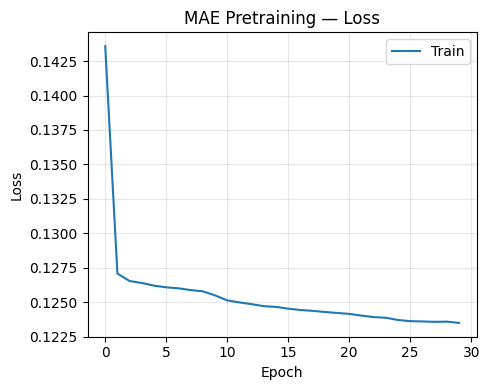


Generating reconstruction visualization...


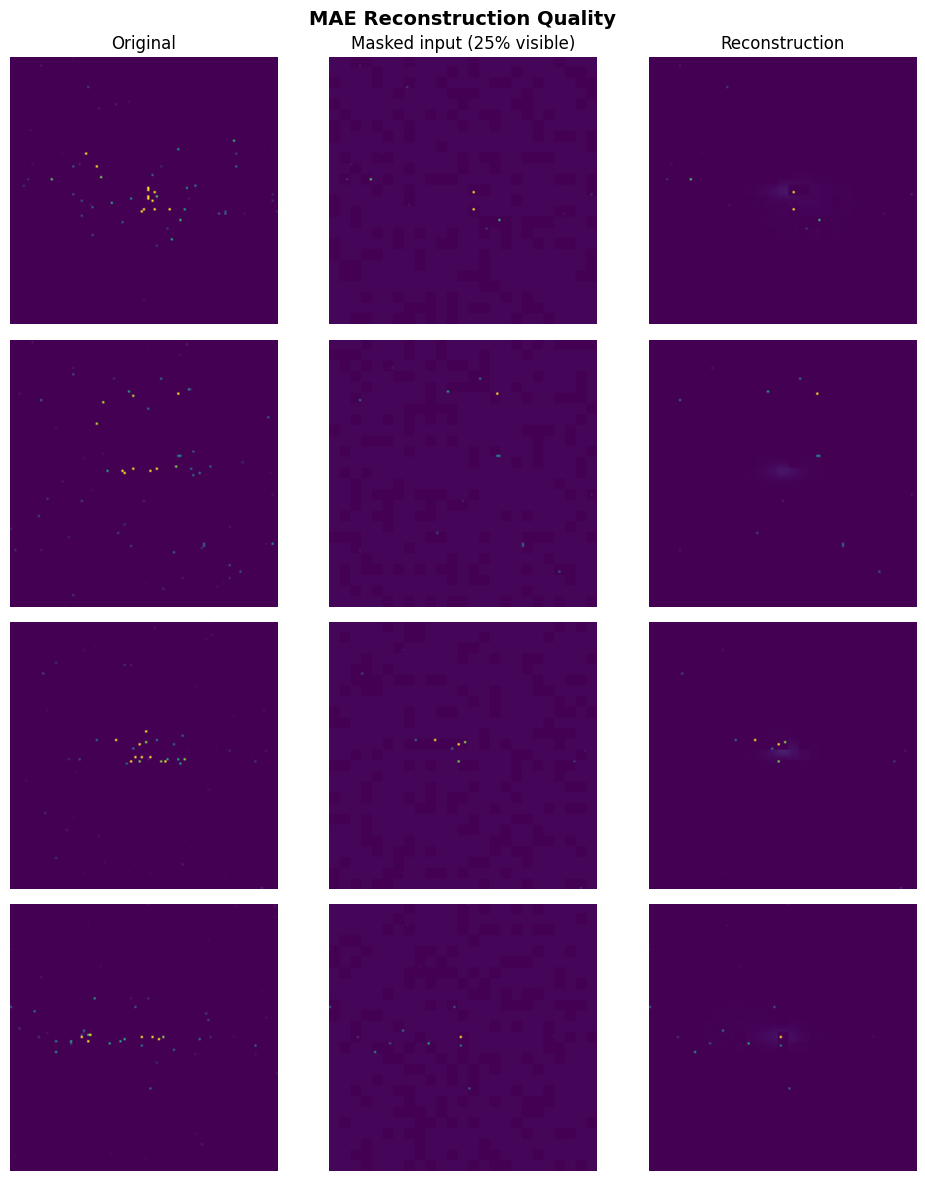

Backed up to Drive.


In [ ]:
mae_model, pretrain_history = pretrain_mae(cfg, pretrain_loader)
plot_training_curves(pretrain_history, "MAE Pretraining")

#Reconstruction Visualization
# Grab a few samples to show Original → Masked → Reconstructed
print("\nGenerating reconstruction visualization...")
sample_batch = next(iter(pretrain_loader))
mae_model.visualize_reconstruction(sample_batch, num_samples=4)

# Backup to Drive
!cp pretrained_weights.pth /content/drive/MyDrive/GSoC_ML4SCI/pretrained_weights.pth
print("Backed up to Drive.")

In [ ]:
with h5py.File('/content/Dataset_Specific_labelled.h5', 'r') as f:
    print("Keys:", list(f.keys()))
    for k in f.keys():
        print(f"  {k}: shape={f[k].shape}")

Keys: ['Y', 'jet']
  Y: shape=(10000, 1)
  jet: shape=(10000, 125, 125, 8)


In [ ]:
MASS_KEY = 'm'

train_ds = H5Dataset('/content/Dataset_Specific_labelled_full.h5',
                     image_key=cfg.image_key, label_key=cfg.label_key,
                     mass_key=MASS_KEY, indices=train_idx, augment=True)
val_ds = H5Dataset('/content/Dataset_Specific_labelled_full.h5',
                   image_key=cfg.image_key, label_key=cfg.label_key,
                   mass_key=MASS_KEY, indices=val_idx, augment=False)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False,
                        num_workers=2, pin_memory=True)
print("Done. mass_key:", MASS_KEY)


Done. mass_key: m


## 16. Phase 3 — Finetune Pretrained Model

Full evaluation: Accuracy, AUC-ROC, Confusion Matrix, Mass MAE, R² score.

/tmp/ipykernel_4706/2896581581.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self._file[self.label_key][real_idx])
/tmp/ipykernel_4706/2896581581.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mass = float(self._file[self.mass_key][real_idx])
/tmp/ipykernel_4706/2896581581.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self._file[self.label_key][real_idx])
/tmp/ipykernel_4706/2896581581.py:51: DeprecationWarning: Conversio

Epoch 1/20 | Train: 140.5646 | Val: 137.1452 | Acc: 0.609/0.752 | MAE: 136.5966


/tmp/ipykernel_4706/2896581581.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self._file[self.label_key][real_idx])
/tmp/ipykernel_4706/2896581581.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mass = float(self._file[self.mass_key][real_idx])
/tmp/ipykernel_4706/2896581581.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self._file[self.label_key][real_idx])
/tmp/ipykernel_4706/2896581581.py:51: DeprecationWarning: Conversio

Epoch 2/20 | Train: 129.9904 | Val: 121.0695 | Acc: 0.741/0.817 | MAE: 120.5737


/tmp/ipykernel_4706/2896581581.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self._file[self.label_key][real_idx])
/tmp/ipykernel_4706/2896581581.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mass = float(self._file[self.mass_key][real_idx])
/tmp/ipykernel_4706/2896581581.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self._file[self.label_key][real_idx])
/tmp/ipykernel_4706/2896581581.py:51: DeprecationWarning: Conversio

...

Epoch 18/20 | Train: 24.3368 | Val: 22.7647 | Acc: 0.849/0.848 | MAE: 22.3348


/tmp/ipykernel_4706/2896581581.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self._file[self.label_key][real_idx])
/tmp/ipykernel_4706/2896581581.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mass = float(self._file[self.mass_key][real_idx])
/tmp/ipykernel_4706/2896581581.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self._file[self.label_key][real_idx])
/tmp/ipykernel_4706/2896581581.py:51: DeprecationWarning: Conversio

Epoch 19/20 | Train: 24.6341 | Val: 22.7177 | Acc: 0.844/0.853 | MAE: 22.2889


/tmp/ipykernel_4706/2896581581.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self._file[self.label_key][real_idx])
/tmp/ipykernel_4706/2896581581.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mass = float(self._file[self.mass_key][real_idx])
/tmp/ipykernel_4706/2896581581.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self._file[self.label_key][real_idx])
/tmp/ipykernel_4706/2896581581.py:51: DeprecationWarning: Conversio

Epoch 20/20 | Train: 24.6655 | Val: 22.7316 | Acc: 0.846/0.852 | MAE: 22.3025


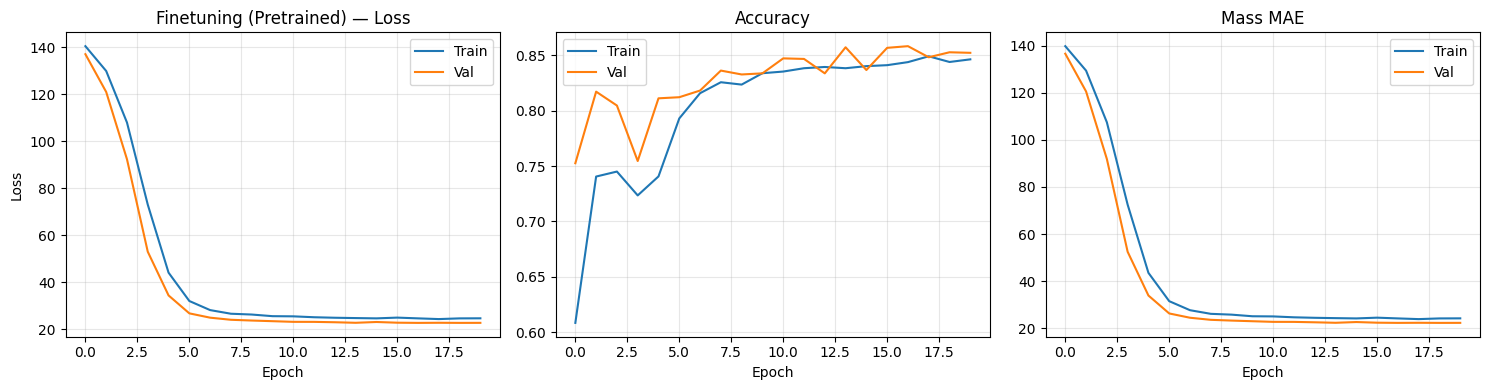


  Pretrained + Finetuned — Full Evaluation


TypeError: tuple indices must be integers or slices, not str

In [ ]:
finetuned_model = LinearViT(cfg)
finetuned_model.load_state_dict(
    torch.load('pretrained_weights.pth', weights_only=True), strict=False
)

finetuned_model, ft_history, ft_results = finetune(
    cfg, finetuned_model, train_loader, val_loader,
    task='both', save_path='finetuned_both.pth', from_scratch=False
)

plot_training_curves(ft_history, "Finetuning (Pretrained)")
ft_metrics = evaluate_all(ft_results, "Pretrained + Finetuned")

!cp finetuned_both.pth /content/drive/MyDrive/GSoC_ML4SCI/finetuned_both.pth



  Pretrained + Finetuned — Full Evaluation
  Classification Accuracy: 0.8520
              precision    recall  f1-score   support

           0       0.84      0.87      0.86      1024
           1       0.86      0.83      0.85       976

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



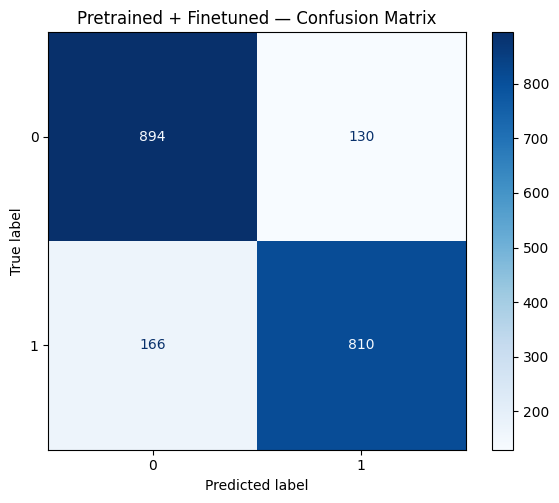

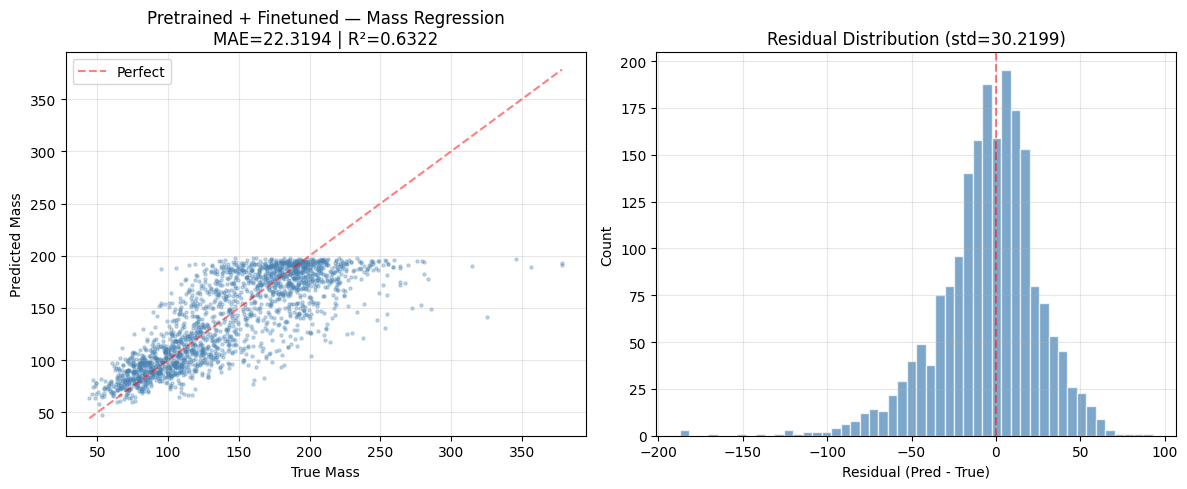

In [ ]:
cls_pred, cls_true, mass_pred, mass_true = ft_results
ft_results_dict = {
    'cls_pred': np.array(cls_pred),
    'cls_true': np.array(cls_true),
    'cls_probs': None,
    'mass_pred': np.array(mass_pred),
    'mass_true': np.array(mass_true),
}
ft_metrics = evaluate_all(ft_results_dict, "Pretrained + Finetuned")
!cp finetuned_both.pth /content/drive/MyDrive/GSoC_ML4SCI/finetuned_both.pth


## 17. Phase 4 — Baseline (From Scratch)

Same architecture, same hyperparameters, **no pretraining**. Random init only.

/tmp/ipykernel_4706/2896581581.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self._file[self.label_key][real_idx])
/tmp/ipykernel_4706/2896581581.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mass = float(self._file[self.mass_key][real_idx])
/tmp/ipykernel_4706/2896581581.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self._file[self.label_key][real_idx])
/tmp/ipykernel_4706/2896581581.py:51: DeprecationWarning: Conversio

Epoch 1/20 | Train: 129.3017 | Val: 124.6365 | Acc: 0.566/0.629 | MAE: 123.9989


/tmp/ipykernel_4706/2896581581.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self._file[self.label_key][real_idx])
/tmp/ipykernel_4706/2896581581.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mass = float(self._file[self.mass_key][real_idx])
/tmp/ipykernel_4706/2896581581.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self._file[self.label_key][real_idx])
/tmp/ipykernel_4706/2896581581.py:51: DeprecationWarning: Conversio

Epoch 2/20 | Train: 119.6100 | Val: 113.1898 | Acc: 0.628/0.713 | MAE: 112.5897


/tmp/ipykernel_4706/2896581581.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self._file[self.label_key][real_idx])
/tmp/ipykernel_4706/2896581581.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mass = float(self._file[self.mass_key][real_idx])
/tmp/ipykernel_4706/2896581581.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self._file[self.label_key][real_idx])
/tmp/ipykernel_4706/2896581581.py:51: DeprecationWarning: Conversio

...

Epoch 18/20 | Train: 25.1805 | Val: 25.5105 | Acc: 0.800/0.802 | MAE: 25.0059


/tmp/ipykernel_4706/2896581581.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self._file[self.label_key][real_idx])
/tmp/ipykernel_4706/2896581581.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mass = float(self._file[self.mass_key][real_idx])
/tmp/ipykernel_4706/2896581581.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self._file[self.label_key][real_idx])
/tmp/ipykernel_4706/2896581581.py:51: DeprecationWarning: Conversio

Epoch 19/20 | Train: 25.0751 | Val: 24.6043 | Acc: 0.804/0.805 | MAE: 24.1118


/tmp/ipykernel_4706/2896581581.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self._file[self.label_key][real_idx])
/tmp/ipykernel_4706/2896581581.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mass = float(self._file[self.mass_key][real_idx])
/tmp/ipykernel_4706/2896581581.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(self._file[self.label_key][real_idx])
/tmp/ipykernel_4706/2896581581.py:51: DeprecationWarning: Conversio

Epoch 20/20 | Train: 24.9779 | Val: 24.5327 | Acc: 0.799/0.806 | MAE: 24.0410


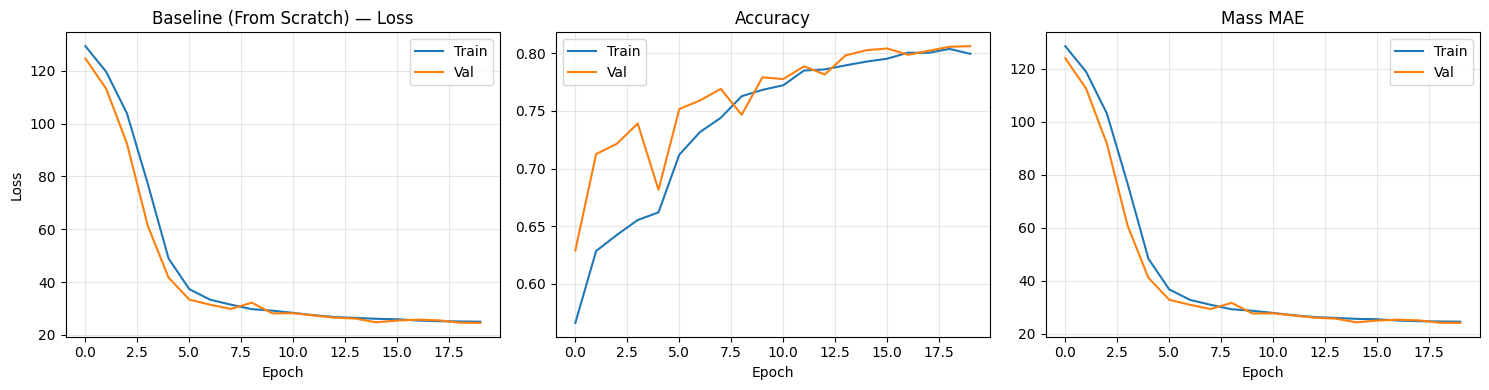


  Baseline (From Scratch) — Full Evaluation


TypeError: tuple indices must be integers or slices, not str

In [ ]:
baseline_model = LinearViT(cfg)

baseline_model, bl_history, bl_results = finetune(
    cfg, baseline_model, train_loader, val_loader,
    task='both', save_path='baseline_both.pth', from_scratch=True
)

plot_training_curves(bl_history, "Baseline (From Scratch)")
bl_metrics = evaluate_all(bl_results, "Baseline (From Scratch)")

!cp baseline_both.pth /content/drive/MyDrive/GSoC_ML4SCI/baseline_both.pth



  Baseline (From Scratch) — Full Evaluation
  Classification Accuracy: 0.8060
              precision    recall  f1-score   support

           0       0.88      0.72      0.79      1024
           1       0.75      0.90      0.82       976

    accuracy                           0.81      2000
   macro avg       0.82      0.81      0.81      2000
weighted avg       0.82      0.81      0.80      2000



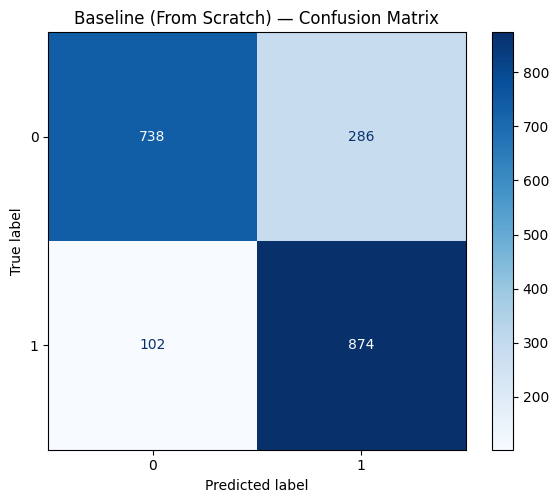

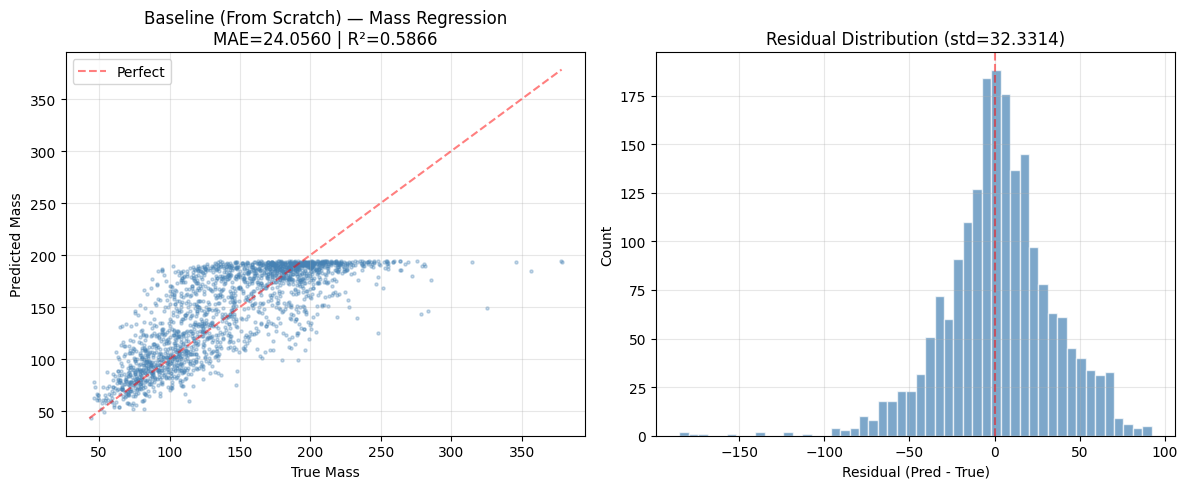

In [ ]:
cls_pred, cls_true, mass_pred, mass_true = bl_results
bl_results_dict = {
    'cls_pred': np.array(cls_pred),
    'cls_true': np.array(cls_true),
    'cls_probs': None,
    'mass_pred': np.array(mass_pred),
    'mass_true': np.array(mass_true),
}
bl_metrics = evaluate_all(bl_results_dict, "Baseline (From Scratch)")
!cp baseline_both.pth /content/drive/MyDrive/GSoC_ML4SCI/baseline_both.pth


In [ ]:
# Replace ft_results and bl_results with dicts for Section 18
ft_results = ft_results_dict
bl_results = bl_results_dict


## 18. Phase 5 — Results Comparison

Complete side-by-side: classification (Accuracy, AUC-ROC) + regression (MAE, R²).
Also overlays training curves to show convergence speed difference.

In [ ]:
if isinstance(ft_results, tuple):
    cls_pred, cls_true, mass_pred, mass_true = ft_results
    ft_results = {
        'cls_pred': np.array(cls_pred),
        'cls_true': np.array(cls_true),
        'cls_probs': None,
        'mass_pred': np.array(mass_pred),
        'mass_true': np.array(mass_true),
    }

if isinstance(bl_results, tuple):
    cls_pred, cls_true, mass_pred, mass_true = bl_results
    bl_results = {
        'cls_pred': np.array(cls_pred),
        'cls_true': np.array(cls_true),
        'cls_probs': None,
        'mass_pred': np.array(mass_pred),
        'mass_true': np.array(mass_true),
    }



  FINAL RESULTS: Pretrained+Finetuned vs From-Scratch Baseline
  Metric                                   Pretrained        Baseline     Winner
  ---------------------------------------------------------------------------
  Classification Accuracy                      0.8520          0.8060 Pretrained ★
  Best Val Loss ↓                             22.7150         24.5327 Pretrained ★
  Epochs to Best ↓                            17.0000         20.0000 Pretrained ★


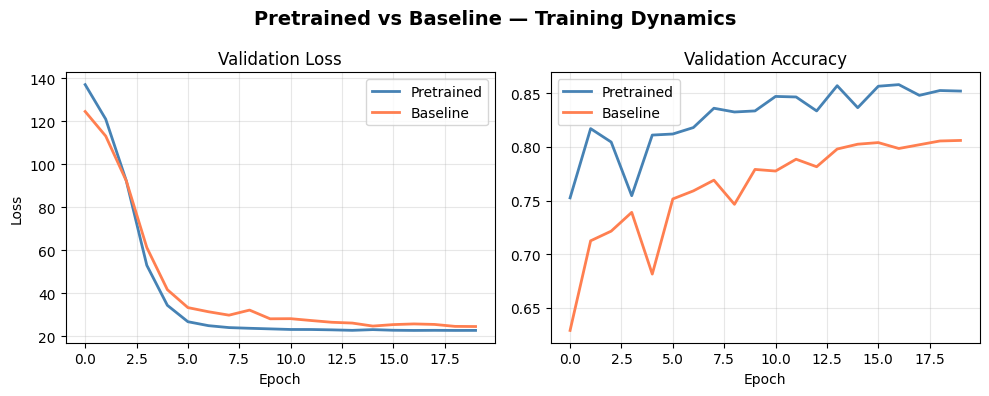


All weights saved. Notebook complete! Ready for submission.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# COMPREHENSIVE COMPARISON TABLE
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("  FINAL RESULTS: Pretrained+Finetuned vs From-Scratch Baseline")
print("="*80)
print(f"  {'Metric':<35} {'Pretrained':>15} {'Baseline':>15} {'Winner':>10}")
print("  " + "-"*75)

comparison = {}

# Classification metrics
if 'accuracy' in ft_metrics:
    comparison['Classification Accuracy'] = (ft_metrics['accuracy'], bl_metrics['accuracy'], False)
if 'auc_roc' in ft_metrics:
    comparison['AUC-ROC'] = (ft_metrics['auc_roc'], bl_metrics['auc_roc'], False)

# Training metrics
comparison['Best Val Loss ↓'] = (min(ft_history['val_loss']), min(bl_history['val_loss']), True)
comparison['Epochs to Best ↓'] = (
    np.argmin(ft_history['val_loss']) + 1,
    np.argmin(bl_history['val_loss']) + 1,
    True
)

for metric, (ft_v, bl_v, lower_better) in comparison.items():
    winner = "Pretrained" if (ft_v < bl_v if lower_better else ft_v > bl_v) else "Baseline"
    marker = " ★" if winner == "Pretrained" else ""
    print(f"  {metric:<35} {ft_v:>15.4f} {bl_v:>15.4f} {winner:>10}{marker}")

print("="*80)

# SIDE-BY-SIDE TRAINING CURVES

n_plots = 1 + bool(ft_history.get('val_acc'))
fig, axes = plt.subplots(1, n_plots, figsize=(5*n_plots, 4))
if n_plots == 1: axes = [axes]

axes[0].plot(ft_history['val_loss'], label='Pretrained', color='steelblue', lw=2)
axes[0].plot(bl_history['val_loss'], label='Baseline', color='coral', lw=2)
axes[0].set(title='Validation Loss', xlabel='Epoch', ylabel='Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

if ft_history.get('val_acc'):
    axes[1].plot(ft_history['val_acc'], label='Pretrained', color='steelblue', lw=2)
    axes[1].plot(bl_history['val_acc'], label='Baseline', color='coral', lw=2)
    axes[1].set(title='Validation Accuracy', xlabel='Epoch')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Pretrained vs Baseline — Training Dynamics', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# ROC CURVES OVERLAY
if ft_results['cls_probs'] is not None:
    fig, ax = plt.subplots(figsize=(7, 5))

    # Pretrained ROC
    ft_probs = ft_results['cls_probs']
    fpr_ft, tpr_ft, _ = roc_curve(ft_results['cls_true'], ft_probs[:, 1])
    auc_ft = roc_auc_score(ft_results['cls_true'], ft_probs[:, 1])
    ax.plot(fpr_ft, tpr_ft, color='steelblue', lw=2, label=f'Pretrained (AUC={auc_ft:.4f})')

    # Baseline ROC
    bl_probs = bl_results['cls_probs']
    fpr_bl, tpr_bl, _ = roc_curve(bl_results['cls_true'], bl_probs[:, 1])
    auc_bl = roc_auc_score(bl_results['cls_true'], bl_probs[:, 1])
    ax.plot(fpr_bl, tpr_bl, color='coral', lw=2, label=f'Baseline (AUC={auc_bl:.4f})')

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
    ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate', title='ROC Comparison: Pretrained vs Baseline')
    ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

print("\nAll weights saved. Notebook complete! Ready for submission.")